In [1]:
import scarf

scarf.set_verbosity('WARNING')

In [2]:
scarf.cytebase.connect("scarf_docs").download_dataset(
    name='kang_15K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True
)

scarf.cytebase.connect("scarf_docs").download_dataset(
    name='kang_14K_ifnb-pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True
)

PosixPath('/tmp/tmp0_f1ngt4/scarf_datasets/kang_14K_ifnb-pbmc_rnaseq')

In [3]:
ds_ctrl = scarf.DataStore(
    'scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr/',
    nthreads=4
)

ds_ctrl

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'cluster_labels', 'RNA_percentMito', 
            'RNA_nCounts', 'RNA_percentRibo', 'RNA_leiden_cluster', 'RNA_nFeatures', 'RNA_UMAP2', 
            'RNA_UMAP1'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

In [4]:
ds_stim = scarf.DataStore(
    'scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr',
    nthreads=4
)

ds_stim

DataStore has 10111 (14446) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'cluster_labels', 'RNA_percentMito', 
            'RNA_percentRibo', 'RNA_nFeatures', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_UMAP2', 
            'RNA_UMAP1'
   RNA assay has 11051 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

In [5]:
scarf.AssayMerge(
    zarr_path='scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=['ctrl', 'stim'],
    merge_assay_name='RNA',
    prepend_text='orig',
    reset_cell_filter=False,
    source_column='sample_id',
    overwrite=True,
).dump()

In [6]:
ds = scarf.DataStore(
    'scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    nthreads=4
)

Minimum cell count (562) is lower than size factor multiplier (1000)



In [7]:
ds

DataStore has 18598 (29065) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'orig_RNA_UMAP1', 'orig_RNA_nCounts', 
            'orig_RNA_percentMito', 'orig_RNA_percentRibo', 'RNA_percentMito', 'orig_RNA_UMAP2', 'RNA_percentRibo', 
            'orig_cluster_labels', 'RNA_nFeatures', 'orig_RNA_leiden_cluster', 'orig_RNA_nFeatures', 'RNA_nCounts', 
            'sample_id'
   RNA assay has 12450 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

In [8]:
ds.cells.head()

,I,ids,names,RNA_percentMito,orig_RNA_nCounts,orig_RNA_percentMito,orig_RNA_UMAP1,orig_RNA_UMAP2,orig_RNA_percentRibo,orig_cluster_labels,RNA_nFeatures,orig_RNA_leiden_cluster,RNA_percentRibo,orig_RNA_nFeatures,RNA_nCounts,sample_id
0,False,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,0.000000,574.0,0.000000,NaN,NaN,20.034843,nan,304.0,-1,20.034843,304.0,574.0,ctrl
1,False,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,0.000000,1682.0,0.000000,NaN,NaN,0.059453,nan,62.0,-1,0.059453,62.0,1682.0,ctrl
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,0.171233,1168.0,0.171233,-1.768571,-5.990341,31.763699,CD4 Memory T,434.0,1,31.763699,434.0,1168.0,ctrl
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,0.185357,2158.0,0.185357,-3.052445,-12.830768,32.483781,CD8 T,837.0,7,32.483781,837.0,2158.0,ctrl
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,0.143369,1395.0,0.143369,-12.654625,-5.425503,34.695341,B,592.0,5,34.695341,592.0,1395.0,ctrl


In [9]:
ds.cells.to_pandas_dataframe(
    ['sample_id'],
    key='I'
)['sample_id'].value_counts()

sample_id
stim    10111
ctrl     8487
Name: count, dtype: int64

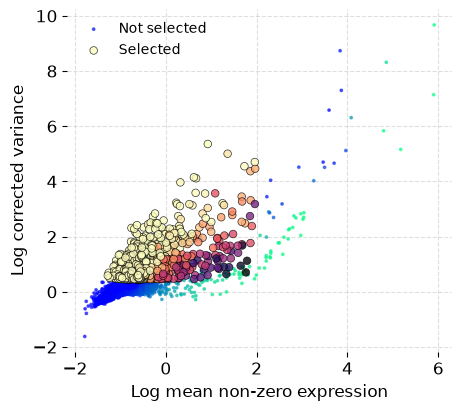

In [10]:
ds.mark_hvgs(
    min_cells=10,
    top_n=2000,
    min_mean=-3, 
    max_mean=2,
    max_var=6
)

In [11]:
normalized = ds.run_normalization(feat_key='hvgs')
pca = ds.run_pca(normalized, dims=25)
ds.build_embedding_initialization(pca)
ann = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)

ArtifactRef(scope='assay', kind='connectivity_map', artifact_id='9bf4279cf949779c296ba520cdfcdf699d1b25d6bbded2514c06f7a91faa86cd', assay='RNA')

In [12]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True
)

In [13]:
ds.cells.head()

,I,ids,names,RNA_percentMito,orig_RNA_nCounts,orig_RNA_UMAP1,orig_RNA_percentRibo,orig_RNA_percentMito,orig_RNA_UMAP2,orig_cluster_labels,RNA_percentRibo,RNA_nFeatures,orig_RNA_nFeatures,RNA_nCounts,orig_RNA_leiden_cluster,RNA_UMAP1,RNA_UMAP2,sample_id
0,False,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,0.000000,574.0,NaN,20.034843,0.000000,NaN,nan,20.034843,304.0,304.0,574.0,-1,NaN,NaN,ctrl
1,False,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,0.000000,1682.0,NaN,0.059453,0.000000,NaN,nan,0.059453,62.0,62.0,1682.0,-1,NaN,NaN,ctrl
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,0.171233,1168.0,-1.768571,31.763699,0.171233,-5.990341,CD4 Memory T,31.763699,434.0,434.0,1168.0,1,-20.308950,8.970496,ctrl
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,0.185357,2158.0,-3.052445,32.483781,0.185357,-12.830768,CD8 T,32.483781,837.0,837.0,2158.0,7,-17.257431,19.211973,ctrl
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,0.143369,1395.0,-12.654625,34.695341,0.143369,-5.425503,B,34.695341,592.0,592.0,1395.0,5,1.665094,6.529717,ctrl


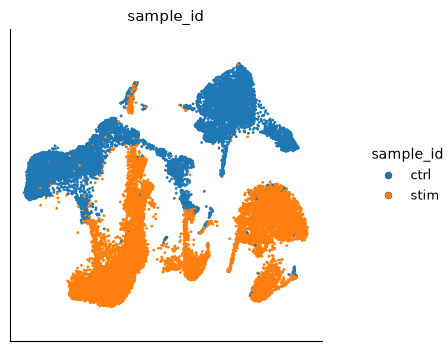

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [14]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='sample_id',
    legend_loc='right',
)

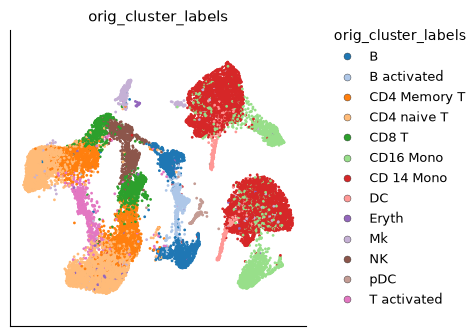

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [15]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
)

In [16]:
ds.cells.insert(
    column_name=f'is_ctrl',
    values=(ds.cells.fetch_all('sample_id') == 'ctrl'),
    overwrite=True
)

In [17]:
pca_partial = ds.run_pca(normalized, dims=25, pca_cell_key='is_ctrl')
ds.build_embedding_initialization(pca_partial)
ann = ds.build_ann_index(pca_partial)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)

ArtifactRef(scope='assay', kind='connectivity_map', artifact_id='8c1d14879d96992c707937138eb23804581729887997e01e0425c4df77f478e3', assay='RNA')

In [18]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True,
    label='pUMAP'
)

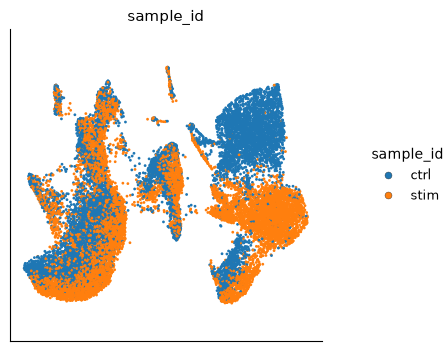

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [19]:
ds.plots.embedding(
    layout_key='RNA_pUMAP',
    color_by='sample_id',
    legend_loc='right',
)

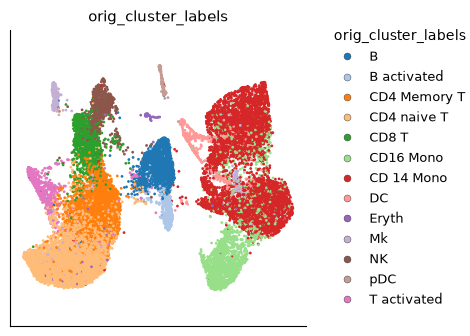

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [20]:
ds.plots.embedding(
    layout_key='RNA_pUMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
)

In [21]:
pca_full = ds.run_pca(normalized, dims=25)
corrected = ds.run_harmony(['sample_id'], pca_full)
ds.build_embedding_initialization(pca_full)
ann = ds.build_ann_index(corrected)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label='hUMAP'
)

ds.run_leiden_clustering(resolution=1.0)

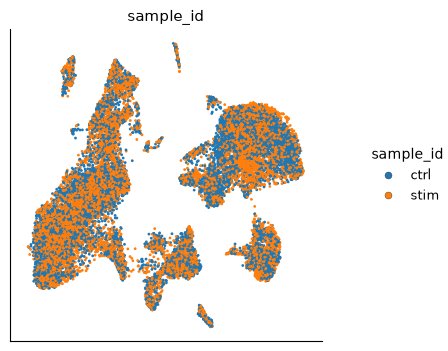

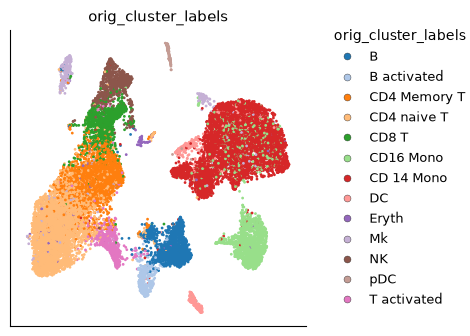

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [22]:
ds.plots.embedding(
    layout_key='RNA_hUMAP',
    color_by='sample_id',
    legend_loc='right',
)

ds.plots.embedding(
    layout_key='RNA_hUMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
)

In [23]:
ds.metric_lisi(
    label_colnames=['sample_id', 'orig_cluster_labels'],
    save_result=True,
    perplexity=7,
)

[('sample_id',
  array([1.62290988, 1.15038782, 1.19165512, ..., 1.65316794, 1.8836371 ,
         1.58161596], shape=(18598,))),
 ('orig_cluster_labels',
  array([1.1365941 , 1.05810118, 1.        , ..., 1.        , 1.        ,
         1.02330442], shape=(18598,)))]

In [24]:
ds.metric_ilisi(batch_colname='sample_id', perplexity=7)

0.48962070347799846

In [25]:
ds.metric_clisi(label_colname='orig_cluster_labels', perplexity=7)

0.9990092426819951

In [26]:
ds.metric_proportional_batch_mixing(label_colname='sample_id', perplexity=7)

0.5081361275609128

In [27]:
ds.metric_graph_connectivity(label_colname='orig_cluster_labels')

0.9570361782044572

In [28]:
ds.metric_graph_silhouette(res_label='leiden_cluster')

array([ 0.13692849,  0.12670735,  0.26044884,  0.2759046 ,  0.36159962,
        0.07861588,  0.34939869,  0.0095868 ,  0.13910108,  0.17214408,
        0.13213062,  0.15002344,  0.25026865, -0.10777408,  0.50931902,
       -0.37751686,  0.10694617])

In [29]:
ds.metric_label_concordance(
    label_columns=['RNA_leiden_cluster', 'orig_cluster_labels'],
    metric='ari'
)

0.5093310673915388